# Current Definition

The gradient of a given function $\nabla f$ with parameters $(x, y)$ is currently defined as

$$
\begin{aligned}
\nabla f &= \frac{\partial f}{\partial x} + \frac{\partial f}{\partial y} \\
         &= \frac{f(x) - f(\Delta x_i)}{2 \Delta x_i} + \frac{f(y) - f(\Delta y_i)}{2 \Delta y_i} \\
         &= a_x + a_y .
\end{aligned}
$$


# Our Idea

We propose to modify the gradient derivative by introducing coupling of the individual components
$$
\begin{aligned}
\nabla f &= \left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right) \\
         &= \left( \frac{f(x) - f(\Delta x_i)}{2 \Delta x_i}, \frac{f(y) - f(\Delta y_i)}{2 \Delta y_i} \right).
\end{aligned}
$$
Where the component sums of the gradient are not summed but rather left independently.

# Theory

We define a coupling frequency for the update increments generated by the gradient of a function $f(x,y)$, evaluated over a discrete iteration index $i \in \mathbb{Z}_{>0}$. Let

$$
G_x^{(i)}=\frac{\partial f}{\partial x}(x_i,y_i),
\qquad
G_y^{(i)}=\frac{\partial f}{\partial y}(x_i,y_i),
$$

and let $\Delta x_i$ and $\Delta y_i$ denote the standard update increments generated from these gradient components. For example, with gradient descent and step size $\eta$,

$$
\Delta x_i=-\eta G_x^{(i)},
\qquad
\Delta y_i=-\eta G_y^{(i)}.
$$

The raw gradient components remain unchanged. Coupling acts only by exchanging the increments applied to $x$ and $y$ at selected iterations.

Define a **swap indicator** $s_i \in \{0,1\}$:

- $s_i=1$ if the **update increments are exchanged** at step $i$, so
  $$
  x_{i+1}=x_i+\Delta y_i,
  \qquad
  y_{i+1}=y_i+\Delta x_i.
  $$
- $s_i=0$ otherwise, giving the standard update
  $$
  x_{i+1}=x_i+\Delta x_i,
  \qquad
  y_{i+1}=y_i+\Delta y_i.
  $$

The empirical swap frequency over $N$ steps is:

$$
\nu_N=\frac{1}{N}\sum_{i=1}^{N}s_i.
$$

We define the **coupling coefficient** as this frequency:

$$
\boxed{C_N(G_x,G_y):=\nu_N}
$$

Thus, a larger $C_N$ means the update increments are exchanged more often, corresponding to stronger or faster coupling. A smaller $C_N$ means exchanges occur less often, so the standard update dominates.

In [1]:
# Current code definition

def numerical_gradient(f, x, eps=1e-6):
    grad = np.zeros_like(x)
    for idx in range(len(x)):
        plus = x.copy()
        minus = x.copy()
        plus[idx] += eps
        minus[idx] -= eps
        grad[idx] = (f(plus) - f(minus)) / (2.0 * eps)
    return grad

## Examples

### Example 1: Computing $\nu_N$ from a swap-indicator array

Suppose over $N=10$ steps we record the swap indicators as an array:

$$
\mathbf{s}=[\,0,\ 1,\ 0,\ 0,\ 1,\ 0,\ 1,\ 0,\ 0,\ 1\,].
$$

The sum of the entries is $\sum_{i=1}^{10}s_i=4$, so the empirical swap frequency is

$$
\nu_{10}=\frac{4}{10}=0.4,
\qquad
C_{10}(G_x,G_y)=0.4.
$$

The update increments were exchanged on 4 of the 10 steps, corresponding to moderate coupling.

### Example 2: Comparing strong and weak coupling

Consider two runs of the same length, $N=10$:

$$
\mathbf{s}^{(A)}=[\,1,\ 1,\ 0,\ 1,\ 1,\ 1,\ 0,\ 1,\ 1,\ 1\,]
\quad\Rightarrow\quad
\nu_{10}^{(A)}=\frac{8}{10}=0.8.
$$

$$
\mathbf{s}^{(B)}=[\,0,\ 0,\ 0,\ 1,\ 0,\ 0,\ 0,\ 0,\ 0,\ 0\,]
\quad\Rightarrow\quad
\nu_{10}^{(B)}=\frac{1}{10}=0.1.
$$

Run $A$ has $C_{10}(G_x,G_y)=0.8$, representing strong or fast coupling because the $x$- and $y$-update increments are exchanged on most steps. Run $B$ has $C_{10}(G_x,G_y)=0.1$, representing weak or slow coupling because the standard increment assignment dominates.

A **periodic** swap schedule is a special case. Swapping the update increments every third step gives

$$
\mathbf{s}=[\,0,\ 0,\ 1,\ 0,\ 0,\ 1,\ 0,\ 0,\ 1,\ \dots\,].
$$

For a finite run of $N$ steps,

$$
\nu_N=\frac{\lfloor N/3\rfloor}{N},
$$

and therefore

$$
\lim_{N\to\infty}\nu_N=\frac{1}{3}.
$$

Thus, $C=1/3$ corresponds asymptotically to one increment exchange every three iterations.

### Example 3: A full trajectory with $f(x,y)=x^2y$

Take $f(x,y)=x^2y$, whose raw partial-gradient components are

$$
G_x^{(i)}
=\frac{\partial f}{\partial x}(x_i,y_i)
=2x_i y_i,
\qquad
G_y^{(i)}
=\frac{\partial f}{\partial y}(x_i,y_i)
=x_i^2.
$$

Using a gradient-descent step size $\eta=0.1$, first calculate the standard increments

$$
\Delta x_i=-\eta G_x^{(i)},
\qquad
\Delta y_i=-\eta G_y^{(i)}.
$$

- **Standard step** ($s_i=0$): $\quad x_{i+1}=x_i+\Delta x_i, \quad y_{i+1}=y_i+\Delta y_i$.
- **Swapped-increment step** ($s_i=1$): $\quad x_{i+1}=x_i+\Delta y_i, \quad y_{i+1}=y_i+\Delta x_i$.

Because the same step size $\eta$ is used for both components, the swapped-increment equations can also be written as

$$
x_{i+1}=x_i-\eta G_y^{(i)},
\qquad
y_{i+1}=y_i-\eta G_x^{(i)}.
$$

This equivalent form does not swap $x_i$ and $y_i$, nor does it redefine or reorder the raw gradient. It only exchanges the already-calculated increments applied to the two coordinates.

Starting from $(x_1,y_1)=(1.0,2.0)$ with swap-indicator array $\mathbf{s}=[\,0,\ 1,\ 0,\ 1,\ 0\,]$ over $N=5$ steps, the trajectory is:

| $i$ | $x_i$ | $y_i$ | $G_x^{(i)}=2x_i y_i$ | $G_y^{(i)}=x_i^2$ | $s_i$ | increment applied to $x$ | increment applied to $y$ |
|---:|---:|---:|---:|---:|:---:|:---:|:---:|
| 1 | 1.0000 | 2.0000 | 4.0000 | 1.0000 | 0 | $\Delta x_1$ | $\Delta y_1$ |
| 2 | 0.6000 | 1.9000 | 2.2800 | 0.3600 | 1 | $\Delta y_2$ | $\Delta x_2$ |
| 3 | 0.5640 | 1.6720 | 1.8860 | 0.3181 | 0 | $\Delta x_3$ | $\Delta y_3$ |
| 4 | 0.3754 | 1.6402 | 1.2314 | 0.1409 | 1 | $\Delta y_4$ | $\Delta x_4$ |
| 5 | 0.3613 | 1.5170 | 1.0962 | 0.1305 | 0 | $\Delta x_5$ | $\Delta y_5$ |
| 6 | 0.2517 | 1.5040 | — | — | — | — | — |

Collected as arrays:

$$
\mathbf{x}=[\,1.0000,\ 0.6000,\ 0.5640,\ 0.3754,\ 0.3613,\ 0.2517\,],
$$

$$
\mathbf{y}=[\,2.0000,\ 1.9000,\ 1.6720,\ 1.6402,\ 1.5170,\ 1.5040\,],
$$

$$
\mathbf{s}=[\,0,\ 1,\ 0,\ 1,\ 0\,].
$$

The coupling coefficient for this run is

$$
C_5(G_x,G_y)
=\nu_5
=\frac{0+1+0+1+0}{5}
=\frac{2}{5}
=0.4.
$$

At the swapped-increment steps $i=2$ and $i=4$, the smaller increment $\Delta y_i$, generated from $G_y^{(i)}$, is applied to $x$, while the larger increment $\Delta x_i$, generated from $G_x^{(i)}$, is applied to $y$. This slows the decay of $x$ and accelerates the decay of $y$ relative to the standard steps. The state coordinates and raw gradient components themselves are never swapped.

### Example 4: Computing $\nu_N$ with NumPy

The empirical coupling coefficient can be calculated directly from a validated binary NumPy array:

In [2]:
import numpy as np

s = np.array([0, 1, 0, 0, 1, 0, 1, 0, 0, 1], dtype=np.int8)

if s.ndim != 1 or s.size == 0:
    raise ValueError("s must be a non-empty one-dimensional array")
if not np.all((s == 0) | (s == 1)):
    raise ValueError("every swap indicator must be either 0 or 1")

N = s.size
nu_N = float(s.sum() / N)  # Equivalently: float(s.mean())
C_N = nu_N

print(nu_N)  # 0.4
print(C_N)   # 0.4


0.4
0.4


Here, `s.sum()` counts the steps on which the update increments were exchanged. Dividing by `N` implements

$$
\nu_N=\frac{1}{N}\sum_{i=1}^{N}s_i,
$$

so this example gives $C_{10}(G_x,G_y)=\nu_{10}=0.4$.

### Example 5: How the revised increment coupling changes the gradient trajectories

To observe the effect of the coupling coefficient on the gradient trajectories, consider the same dynamics as in Example 3: $f(x,y)=x^2y$, step size $\eta=0.1$, initial state $(x_1,y_1)=(1.0,2.0)$, and $N=40$ update steps. We compare four **periodic increment-swap schedules**, each realizing a different coupling coefficient over the 40-step run:

| Schedule | Swap-indicator pattern | $C_{40}(G_x,G_y)=\nu_{40}$ |
|---|---|:---:|
| no swaps | $\mathbf{s}=[\,0,\ 0,\ 0,\ 0,\ \dots\,]$ | $0$ |
| swap every 4th step | $\mathbf{s}=[\,0,\ 0,\ 0,\ 1,\ 0,\ 0,\ 0,\ 1,\ \dots\,]$ | $0.25$ |
| swap every 2nd step | $\mathbf{s}=[\,0,\ 1,\ 0,\ 1,\ 0,\ 1,\ \dots\,]$ | $0.5$ |
| swap every step | $\mathbf{s}=[\,1,\ 1,\ 1,\ 1,\ \dots\,]$ | $1$ |

At every iteration, the raw gradient components retain their original definitions:

$$
G_x^{(i)}=2x_i y_i,
\qquad
G_y^{(i)}=x_i^2.
$$

The standard gradient-descent increments are calculated first:

$$
\Delta x_i=-\eta G_x^{(i)},
\qquad
\Delta y_i=-\eta G_y^{(i)}.
$$

The swap indicator changes only which increment is applied to each coordinate:

$$
s_i=0:
\quad
x_{i+1}=x_i+\Delta x_i,
\qquad
y_{i+1}=y_i+\Delta y_i,
$$

$$
s_i=1:
\quad
x_{i+1}=x_i+\Delta y_i,
\qquad
y_{i+1}=y_i+\Delta x_i.
$$

For the common scalar step size $\eta=0.1$ used in this example,

$$
\operatorname{swap}(-\eta G_x^{(i)},-\eta G_y^{(i)})
=(-\eta G_y^{(i)},-\eta G_x^{(i)}).
$$

Consequently, the revised delta-first procedure produces the same numerical trajectory as the shorthand equations $x_{i+1}=x_i-\eta G_y^{(i)}$ and $y_{i+1}=y_i-\eta G_x^{(i)}$ on an indicated step. This numerical equivalence holds here because the same scalar $\eta$ multiplies both gradient components. The interpretation is nevertheless different: the completed increments are exchanged, not the gradients or state coordinates.

For example, the $C_{40}=0.5$ schedule begins with $s_1=0$ and $s_2=1$. After the first standard step, the state is

$$
(x_2,y_2)=(0.600,1.900).
$$

At the second step, the unchanged raw gradient and ordinary increments are

$$
(G_x^{(2)},G_y^{(2)})=(2.280,0.360),
$$

$$
(\Delta x_2,\Delta y_2)=(-0.228,-0.036).
$$

Because $s_2=1$, only the increments are exchanged:

$$
(\widetilde{\Delta x_2},\widetilde{\Delta y_2})
=(-0.036,-0.228).
$$

The next state is therefore

$$
(x_3,y_3)
=(0.600,1.900)+(-0.036,-0.228)
=(0.564,1.672),
$$

not $(1.900,0.600)$. The swapped increments alter the subsequent state, causing later evaluations of the unchanged gradient formulas to follow different trajectories.

Each panel below plots the raw gradient trajectories $G_x^{(i)}=2x_i y_i$ and $G_y^{(i)}=x_i^2$ against the iteration index for one value of $C_{40}(G_x,G_y)$:

![Raw gradient trajectories of f(x,y) = x²y after frequency-coupled increments](coupling-frequency-gradients.png)

Recomputing all four runs with the revised delta-first algorithm gives:

| $C_{40}$ | Final $x_{41}$ | Final $y_{41}$ |
|---:|---:|---:|
| $0$ | $0.000000$ | $1.841126$ |
| $0.25$ | $0.000002$ | $1.724836$ |
| $0.5$ | $0.001498$ | $1.243038$ |
| $1$ | $0.193474$ | $0.068278$ |

Reading from left to right:

- **$C_{40}=0$ (uncoupled):** each coordinate receives its own standard increment. The relatively large increment $\Delta x_i$, generated from $G_x^{(i)}$, drives $x$ toward zero within approximately 10 steps. Because both $G_x=2xy$ and $G_y=x^2$ depend on $x$, both gradient components also approach zero. The endpoint is $(x,y)\approx(0.000,1.841)$, so $y$ changes comparatively little.
- **$C_{40}=0.25$:** every fourth step applies $\Delta y_i$ to $x$ and $\Delta x_i$ to $y$. These increment exchanges produce the visible kinks in the $G_x$ trajectory. On a swapped step, $x$ receives the smaller-magnitude increment generated from $G_y$, delaying the decay of $x$ and allowing the gradient components to remain nonzero slightly longer. The endpoint is $(x,y)\approx(0.000,1.725)$.
- **$C_{40}=0.5$:** the increments are exchanged every second step. On alternating iterations, $x$ receives the smaller-magnitude increment $\Delta y_i$, while $y$ receives the larger-magnitude increment $\Delta x_i$. This produces a staircase-like decay in $G_x$, prolongs both gradient trajectories, and causes $y$ to decay substantially. The endpoint is $(x,y)\approx(0.002,1.243)$.
- **$C_{40}=1$ (fully coupled):** the increments are exchanged on every step. Therefore, $x$ always receives $\Delta y_i$, generated from $G_y^{(i)}$, while $y$ always receives $\Delta x_i$, generated from $G_x^{(i)}$. Both gradient trajectories decay more slowly and smoothly, and $y$ is driven close to zero. The endpoint is $(x,y)\approx(0.194,0.068)$.

For this experiment, increasing $C_{40}$ applies the larger-magnitude increment $\Delta x_i$, generated from $G_x^{(i)}$, to $y$ more frequently while applying the smaller-magnitude increment $\Delta y_i$, generated from $G_y^{(i)}$, to $x$. This prolongs the gradient trajectories and shifts more of the decay from $x$ to $y$. The coupling redirects update increments only; it does not exchange the state coordinates or the raw gradient components.

Saved coupling-variable-swap-gradients.png


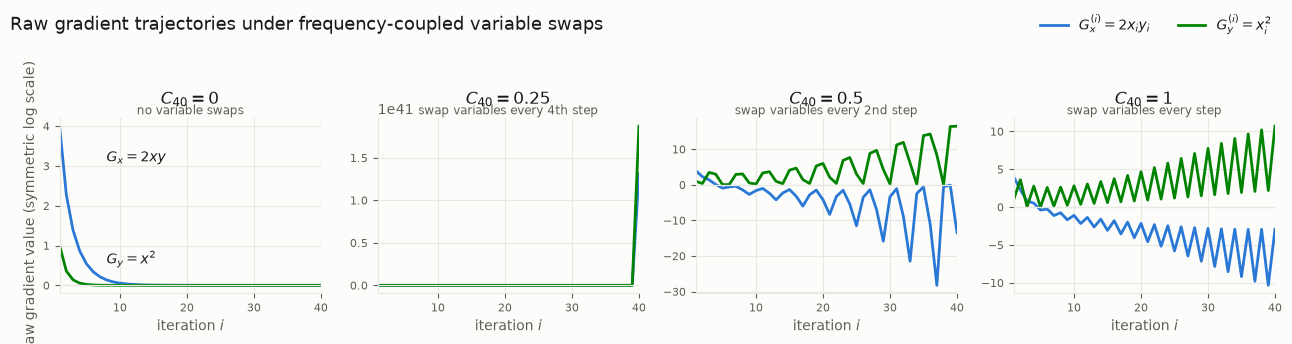

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


SURFACE = "#fcfcfb"
TEXT_PRIMARY = "#1a1a19"
TEXT_SECONDARY = "#5f5e56"
GRID = "#e8e7e2"
C_GX = "#2a78d6"  # Blue: raw G_x.
C_GY = "#008300"  # Green: raw G_y.

N, ETA = 40, 0.1
X0, Y0 = 1.0, 2.0


def run(period):
    """Return raw gradients and C for an intentional variable-swap schedule.

    ``period=0`` never swaps variables.  ``period=p`` exchanges the complete
    post-update state on steps whose one-based index is divisible by ``p``.
    The raw gradient is evaluated before both the update and state exchange.
    """
    if isinstance(period, (bool, np.bool_)) or not isinstance(
        period, (int, np.integer)
    ):
        raise TypeError("period must be a non-negative integer")
    period = int(period)
    if period < 0:
        raise ValueError("period must be a non-negative integer")

    x, y = X0, Y0
    swap_indicators = np.zeros(N, dtype=np.int8)
    gradient_x = np.empty(N, dtype=np.float64)
    gradient_y = np.empty(N, dtype=np.float64)

    for iteration in range(1, N + 1):
        index = iteration - 1

        # 1. Evaluate the raw gradient before the state exchange.
        gradient_x[index] = 2.0 * x * y
        gradient_y[index] = x**2

        # 2. Record whether this step includes the intentional state swap.
        swap_indicators[index] = int(
            period > 0 and iteration % period == 0
        )

        # 3. Perform the standard gradient update.
        x = x - ETA * gradient_x[index]
        y = y - ETA * gradient_y[index]

        # 4. Feature: exchange the whole post-update state when indicated.
        if swap_indicators[index] == 1:
            x, y = y, x

        if not np.all(
            np.isfinite((gradient_x[index], gradient_y[index], x, y))
        ):
            raise FloatingPointError(
                f"non-finite dynamics encountered at iteration {iteration}"
            )

    coefficient = float(swap_indicators.mean())
    return gradient_x, gradient_y, coefficient


def build_figure():
    """Build the readable four-panel variable-swap comparison."""
    panels = [
        (0, "no variable swaps"),
        (4, "swap variables every 4th step"),
        (2, "swap variables every 2nd step"),
        (1, "swap variables every step"),
    ]

    # The schedules occupy radically different ranges, so sharing one linear
    # y-axis would flatten three panels.  Independent symlog axes preserve
    # negative values, behavior around zero, and growth up to about 1e41.
    figure, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=False)
    figure.patch.set_facecolor(SURFACE)
    iterations = np.arange(1, N + 1)

    for axis, (period, schedule_label) in zip(axes, panels):
        gradient_x, gradient_y, coefficient = run(period)

        axis.set_facecolor(SURFACE)
        axis.plot(iterations, gradient_x, color=C_GX, lw=2)
        axis.plot(iterations, gradient_y, color=C_GY, lw=2)
        # axis.set_yscale("symlog", linthresh=1e-2, linscale=1.0)
        axis.axhline(0.0, color=GRID, lw=0.9)
        axis.set_title(
            f"$C_{{40}} = {coefficient:g}$",
            fontsize=12,
            color=TEXT_PRIMARY,
            pad=10,
        )
        axis.text(
            0.5,
            1.005,
            schedule_label,
            transform=axis.transAxes,
            ha="center",
            va="bottom",
            fontsize=8.5,
            color=TEXT_SECONDARY,
        )
        axis.grid(True, color=GRID, lw=0.8)
        axis.set_axisbelow(True)

        for spine in ("top", "right"):
            axis.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            axis.spines[spine].set_color(GRID)

        axis.tick_params(colors=TEXT_SECONDARY, labelsize=8)
        axis.set_xlabel("iteration $i$", fontsize=10, color=TEXT_SECONDARY)
        axis.set_xlim(1, N)

    axes[0].set_ylabel(
        "raw gradient value (symmetric log scale)",
        fontsize=10,
        color=TEXT_SECONDARY,
    )

    # Direct labels on the uncoupled panel and one legend for the figure.
    uncoupled_gradient_x, uncoupled_gradient_y, _ = run(0)
    axes[0].annotate(
        "$G_x = 2xy$",
        xy=(4, uncoupled_gradient_x[3]),
        xytext=(8, 3.1),
        fontsize=10,
        color=TEXT_PRIMARY,
    )
    axes[0].annotate(
        "$G_y = x^2$",
        xy=(4, uncoupled_gradient_y[3]),
        xytext=(8, 0.55),
        fontsize=10,
        color=TEXT_PRIMARY,
    )
    figure.legend(
        handles=[
            plt.Line2D(
                [],
                [],
                color=C_GX,
                lw=2,
                label="$G_x^{(i)} = 2x_i y_i$",
            ),
            plt.Line2D(
                [],
                [],
                color=C_GY,
                lw=2,
                label="$G_y^{(i)} = x_i^2$",
            ),
        ],
        loc="upper right",
        ncol=2,
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0.99, 1.02),
        labelcolor=TEXT_PRIMARY,
    )
    figure.suptitle(
        "Raw gradient trajectories under frequency-coupled variable swaps",
        x=0.01,
        ha="left",
        fontsize=13,
        color=TEXT_PRIMARY,
    )
    figure.tight_layout(rect=[0, 0, 1, 0.90])
    return figure


def main():
    """Generate the variable-swap plot next to this script."""
    figure = build_figure()
    output_path = Path(
        "coupling-variable-swap-gradients.png"
    )
    figure.savefig(
        output_path,
        dpi=160,
        facecolor=SURFACE,
        bbox_inches="tight",
    )
    print(f"Saved {output_path}")
    
if __name__ == "__main__":
    main()


In [4]:
import pandas as pd

periods = [0, 4, 2, 1]
C_vals  = [0, 0.25, 0.5, 1]
data = {}
for per, C in zip(periods, C_vals):
    Gx, Gy, _ = run(per)
    data[f'C={C} Gx'] = Gx
    data[f'C={C} Gy'] = Gy

df = pd.DataFrame(data, index=np.arange(1, N+1))
# print(df.head(10).to_string())   # first 10 iterations
print(df.to_string()) # for all 40

          C=0 Gx        C=0 Gy     C=0.25 Gx     C=0.25 Gy   C=0.5 Gx   C=0.5 Gy     C=1 Gx     C=1 Gy
1   4.000000e+00  1.000000e+00  4.000000e+00  1.000000e+00   4.000000   1.000000   4.000000   1.000000
2   2.280000e+00  3.600000e-01  2.280000e+00  3.600000e-01   2.280000   0.360000   2.280000   3.610000
3   1.386816e+00  1.383840e-01  1.386816e+00  1.383840e-01   1.386816   3.474496   0.799216   0.057121
4   8.633535e-01  5.443748e-02  8.633535e-01  5.443748e-02   0.084715   2.976724   0.530141   2.776515
5   5.422845e-01  2.160402e-02  5.422845e-01  3.402984e+00  -0.937817   0.074596  -0.382582   0.014060
6   3.418114e-01  8.603416e-03 -6.922582e-01  3.205852e+00  -0.613124   0.032163  -0.258914   2.598118
7   2.157492e-01  3.430851e-03 -1.911417e+00  3.458541e+00  -0.402751   2.911020  -1.114091   0.115686
8   1.362549e-01  1.368893e-03 -3.526468e+00  4.206014e+00  -1.429047   3.050074  -0.743877   2.644496
9   8.606977e-02  5.463001e-04 -6.154681e+00  1.639312e+00  -2.698512   0

Saved coupling-manual-swap-gradients.png


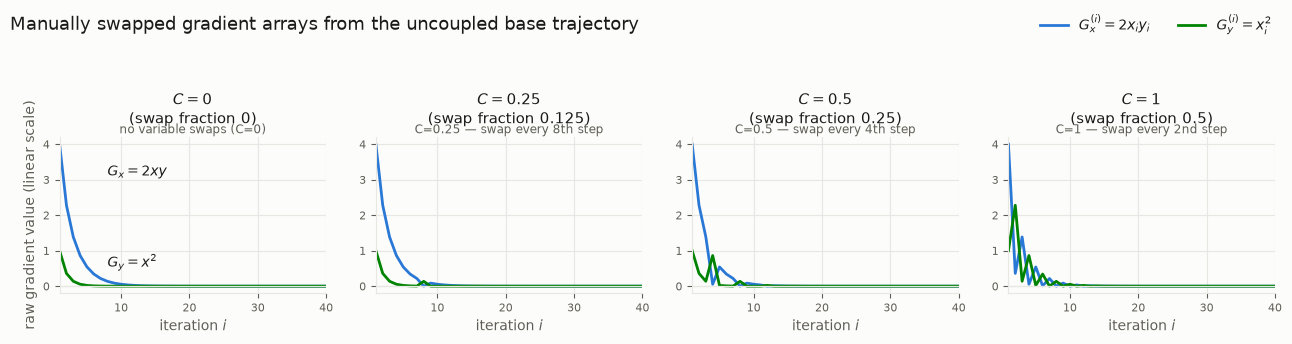

In [6]:
# =============================================================================
#  New cell: manually swap Gx/Gy according to C  (don't use run() for C>0)
# =============================================================================
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# ---- constants (same as your scaffold) ----
SURFACE = "#fcfcfb"
TEXT_PRIMARY = "#1a1a19"
TEXT_SECONDARY = "#5f5e56"
GRID = "#e8e7e2"
C_GX = "#2a78d6"
C_GY = "#008300"

N, ETA = 40, 0.1
X0, Y0 = 1.0, 2.0

# ---- original run() function (needed for the uncoupled baseline) ----
def run(period):
    if isinstance(period, (bool, np.bool_)) or not isinstance(period, (int, np.integer)):
        raise TypeError("period must be a non-negative integer")
    period = int(period)
    if period < 0:
        raise ValueError("period must be a non-negative integer")

    x, y = X0, Y0
    swap_indicators = np.zeros(N, dtype=np.int8)
    gradient_x = np.empty(N, dtype=np.float64)
    gradient_y = np.empty(N, dtype=np.float64)

    for iteration in range(1, N + 1):
        index = iteration - 1
        gradient_x[index] = 2.0 * x * y
        gradient_y[index] = x ** 2
        swap_indicators[index] = int(period > 0 and iteration % period == 0)
        x = x - ETA * gradient_x[index]
        y = y - ETA * gradient_y[index]
        if swap_indicators[index] == 1:
            x, y = y, x
        if not np.all(np.isfinite((gradient_x[index], gradient_y[index], x, y))):
            raise FloatingPointError(f"non-finite dynamics at iteration {iteration}")
    coefficient = float(swap_indicators.mean())
    return gradient_x, gradient_y, coefficient

# ---- uncoupled base arrays ----
Gx0, Gy0, _ = run(0)

# ---- mapping C -> swap period ----
# C=1   → swap every 2nd step (½ swapped)
# C=0.5 → swap every 4th step (¼ swapped)
# C=0.25→ swap every 8th step (⅛ swapped)
# C=0   → never swap
panels = [
    (0,   0, "no variable swaps (C=0)"),
    (0.25,8, "C=0.25 — swap every 8th step"),
    (0.5, 4, "C=0.5 — swap every 4th step"),
    (1,   2, "C=1 — swap every 2nd step"),
]

# ---- build the figure ----
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=False)
fig.patch.set_facecolor(SURFACE)
iterations = np.arange(1, N + 1)

for ax, (C, period, label) in zip(axes, panels):
    # --- create swapped arrays ---
    if period == 0:
        Gx, Gy = Gx0.copy(), Gy0.copy()
        swap_frac = 0.0
    else:
        # indices to swap: 1‑based step divisible by period
        swap_mask = (iterations % period) == 0
        Gx = np.where(swap_mask, Gy0, Gx0)
        Gy = np.where(swap_mask, Gx0, Gy0)
        swap_frac = swap_mask.mean()

    # --- plot ---
    ax.set_facecolor(SURFACE)
    ax.plot(iterations, Gx, color=C_GX, lw=2)
    ax.plot(iterations, Gy, color=C_GY, lw=2)
    ax.axhline(0.0, color=GRID, lw=0.9)
    # title shows C and the actual swap fraction
    ax.set_title(f"$C = {C}$\n(swap fraction {swap_frac:.3g})",
                 fontsize=11, color=TEXT_PRIMARY, pad=10)
    ax.text(0.5, 1.005, label, transform=ax.transAxes, ha="center",
            va="bottom", fontsize=8.5, color=TEXT_SECONDARY)
    ax.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(GRID)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    ax.set_xlabel("iteration $i$", fontsize=10, color=TEXT_SECONDARY)
    ax.set_xlim(1, N)

# left‑most ylabel
axes[0].set_ylabel("raw gradient value (linear scale)",
                   fontsize=10, color=TEXT_SECONDARY)

# direct annotations on the C=0 panel
axes[0].annotate("$G_x = 2xy$", xy=(4, Gx0[3]), xytext=(8, 3.1),
                 fontsize=10, color=TEXT_PRIMARY)
axes[0].annotate("$G_y = x^2$", xy=(4, Gy0[3]), xytext=(8, 0.55),
                 fontsize=10, color=TEXT_PRIMARY)

# figure‑wide legend
fig.legend(
    handles=[plt.Line2D([], [], color=C_GX, lw=2, label="$G_x^{(i)} = 2x_i y_i$"),
             plt.Line2D([], [], color=C_GY, lw=2, label="$G_y^{(i)} = x_i^2$")],
    loc="upper right", ncol=2, frameon=False, fontsize=10,
    bbox_to_anchor=(0.99, 1.02), labelcolor=TEXT_PRIMARY,
)
fig.suptitle(
    "Manually swapped gradient arrays from the uncoupled base trajectory",
    x=0.01, ha="left", fontsize=13, color=TEXT_PRIMARY,
)
fig.tight_layout(rect=[0, 0, 1, 0.90])

# ---- save ----
out = Path("coupling-manual-swap-gradients.png")
fig.savefig(out, dpi=160, facecolor=SURFACE, bbox_inches="tight")
print(f"Saved {out}")

In [7]:
# ---------------------------------------------------------------------------
#  Analog of the DataFrame print, now using manually swapped base arrays
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np

# 1. Base (uncoupled) gradients
Gx0, Gy0, _ = run(0)          # run(0) must be defined in the session

# 2. Manual swapping according to the coupling coefficients
data = {}
for C, period in [(0, 0), (0.25, 8), (0.5, 4), (1, 2)]:
    if period == 0:
        Gx, Gy = Gx0.copy(), Gy0.copy()
    else:
        swap_mask = (np.arange(1, N + 1) % period) == 0
        Gx = np.where(swap_mask, Gy0, Gx0)
        Gy = np.where(swap_mask, Gx0, Gy0)
    data[f'C={C} Gx'] = Gx
    data[f'C={C} Gy'] = Gy

df = pd.DataFrame(data, index=np.arange(1, N + 1))
print(df.to_string())   # full 40‑iteration table

          C=0 Gx        C=0 Gy     C=0.25 Gx     C=0.25 Gy      C=0.5 Gx      C=0.5 Gy        C=1 Gx        C=1 Gy
1   4.000000e+00  1.000000e+00  4.000000e+00  1.000000e+00  4.000000e+00  1.000000e+00  4.000000e+00  1.000000e+00
2   2.280000e+00  3.600000e-01  2.280000e+00  3.600000e-01  2.280000e+00  3.600000e-01  3.600000e-01  2.280000e+00
3   1.386816e+00  1.383840e-01  1.386816e+00  1.383840e-01  1.386816e+00  1.383840e-01  1.386816e+00  1.383840e-01
4   8.633535e-01  5.443748e-02  8.633535e-01  5.443748e-02  5.443748e-02  8.633535e-01  5.443748e-02  8.633535e-01
5   5.422845e-01  2.160402e-02  5.422845e-01  2.160402e-02  5.422845e-01  2.160402e-02  5.422845e-01  2.160402e-02
6   3.418114e-01  8.603416e-03  3.418114e-01  8.603416e-03  3.418114e-01  8.603416e-03  8.603416e-03  3.418114e-01
7   2.157492e-01  3.430851e-03  2.157492e-01  3.430851e-03  2.157492e-01  3.430851e-03  2.157492e-01  3.430851e-03
8   1.362549e-01  1.368893e-03  1.368893e-03  1.362549e-01  1.368893e-03  1.3625

### 1. Preface

Below are the mathematical equations implemented in each scientific section of the program, together with explanatory comments that link them to the code.

---

### 2. Geometric Algebra Setup

The code uses the 3‑dimensional Euclidean geometric algebra $\mathcal{G}(3,0)$ with orthonormal basis vectors $\mathbf{e}_1,\mathbf{e}_2,\mathbf{e}_3$.  
The scalar part of a multivector is extracted with:

$$
\langle A \rangle_0 = \text{scalar}(A)
$$

In the code this is the function `scalar_part()`; it returns the scalar component of a pure scalar or of the Clifford product of vectors.

---

### 3. Spherical Pendulum Model

The spherical pendulum consists of a point mass $m$ on a massless rod of length $R$, moving on the surface of a sphere under gravity $g$. The configuration is described by the polar angle $\theta$ (from the vertical $z$-axis) and the azimuthal angle $\phi$.

#### Position on the sphere

$$
\mathbf{r}(\theta,\phi) = R\bigl(\sin\theta\cos\phi\,\mathbf{e}_1 + \sin\theta\sin\phi\,\mathbf{e}_2 + \cos\theta\,\mathbf{e}_3\bigr)
\tag{1}
$$

Code: `position_from_angles(theta, phi)`

#### Velocity

The natural tangent basis vectors are

$$
\begin{aligned}
\mathbf{e}_\theta &= \cos\theta\cos\phi\,\mathbf{e}_1 + \cos\theta\sin\phi\,\mathbf{e}_2 - \sin\theta\,\mathbf{e}_3,\$$2pt]
\mathbf{e}_\phi &= -\sin\phi\,\mathbf{e}_1 + \cos\phi\,\mathbf{e}_2.
\end{aligned}
$$

The velocity is then

$$
\mathbf{v} = \dot{\mathbf{r}} = R\bigl(\dot\theta\,\mathbf{e}_\theta + \sin\theta\,\dot\phi\,\mathbf{e}_\phi\bigr).
\tag{2}
$$
now return only the advanced mathematical (especially geometric algebra) equations not covered here (not scientific)
Code: `velocity_from_angles(theta, phi, theta_dot, phi_dot)`

#### Kinetic and potential energy

$$
T = \frac{1}{2}m\,\mathbf{v}\cdot\mathbf{v} = \frac{1}{2}m\,R^2\bigl(\dot\theta^2 + \sin^2\theta\,\dot\phi^2\bigr),
\qquad
V = m g R \cos\theta.
\tag{3}
$$

The Lagrangian is

$$
L(\theta,\phi,\dot\theta,\dot\phi) = T - V.
\tag{4}
$$

In the code the kinetic energy is computed using the geometric algebra inner product $\mathbf{v}\vert\mathbf{v}$ (scalar part of $\mathbf{v}^2$) and multiplying by $m/2$.

---

### 4. Euler–Lagrange Equations (Numerical Solution)

The equations of motion are the Euler–Lagrange equations for a system with two degrees of freedom:

$$
\frac{d}{dt}\!\left(\frac{\partial L}{\partial \dot q_i}\right) - \frac{\partial L}{\partial q_i} = 0,
\qquad q = (\theta,\phi).
\tag{5}
$$

The code does **not** derive the equations symbolically; instead it numerically evaluates the necessary derivatives using central differences. The function `euler_lagrange_acceleration(q, q_dot)` computes $\ddot q = (\ddot\theta,\ddot\phi)$ by solving a $2\times2$ linear system.

The chain rule gives

$$
\frac{d}{dt}\!\left(\frac{\partial L}{\partial \dot q}\right)
= \frac{\partial^2 L}{\partial \dot q^2}\,\ddot q + \frac{\partial^2 L}{\partial \dot q\,\partial q}\,\dot q .
$$

Defining

$$
\mathbf{f} = \frac{\partial L}{\partial q}
\quad\text{(generalised force)},
\qquad
\mathbf{M} = \frac{\partial^2 L}{\partial \dot q^2}
\quad\text{(mass matrix)},
\qquad
\mathbf{C} = \frac{\partial^2 L}{\partial \dot q\,\partial q}\,\dot q
\quad\text{(convective term)},
$$

the equations become

$$
\mathbf{M}\,\ddot q = \mathbf{f} - \mathbf{C}.
\tag{6}
$$

The code computes each quantity numerically:

* **Force** $\mathbf{f}$:  
  $$
  f_i \approx \frac{L(q + \varepsilon\,\mathbf{e}_i,\dot q) - L(q - \varepsilon\,\mathbf{e}_i,\dot q)}{2\varepsilon}.
  $$
  This is `numerical_gradient` applied to `lagrangian_at_q`.

* **Momentum** $\mathbf{p} = \partial L/\partial\dot q$ (needed for the mass matrix and convective term):  
  $$
  p_i(\dot q) \approx \frac{L(q,\dot q + \varepsilon\,\mathbf{e}_i) - L(q,\dot q - \varepsilon\,\mathbf{e}_i)}{2\varepsilon}.
  $$
  This is `momentum_at_q_dot` inside `euler_lagrange_acceleration`.

* **Mass matrix** $\mathbf{M}$:  
  $$
  M_{ij} \approx \frac{p_i(\dot q + \varepsilon\,\mathbf{e}_j) - p_i(\dot q - \varepsilon\,\mathbf{e}_j)}{2\varepsilon}.
  $$
  (column $j$ of $\mathbf{M}$ is obtained by a central difference of $\mathbf{p}$ in the direction of $\dot q_j$).

* **Convective term** $\mathbf{C}$:  
  Using the finite‑difference approximation along the velocity direction,
  $$
  \mathbf{C} \approx \frac{\mathbf{p}(q + \varepsilon\,\dot q) - \mathbf{p}(q - \varepsilon\,\dot q)}{2\varepsilon}.
  $$
  This corresponds to the code computing `momentum_at_q` with $q_\pm = q \pm \varepsilon\,\dot q$.

Finally, the acceleration is solved from

$$
\ddot q = \mathbf{M}^{-1}(\mathbf{f} - \mathbf{C}).
$$

The first‑order right‑hand side returned by `ode_rhs` is

$$
\frac{d}{dt}
\begin{pmatrix}
\theta \\ \phi \\ \dot\theta \\ \dot\phi
\end{pmatrix}
=
\begin{pmatrix}
\dot\theta \\ \dot\phi \\ \ddot\theta \\ \ddot\phi
\end{pmatrix}.
\tag{7}
$$

---

### 5. Numerical Integration

The ODE (7) is integrated with the classic fourth‑order Runge–Kutta method:

$$
\begin{aligned}
\mathbf{k}_1 &= \mathbf{f}(t_n, \mathbf{y}_n),\\
\mathbf{k}_2 &= \mathbf{f}(t_n+\tfrac{\Delta t}{2}, \mathbf{y}_n + \tfrac{\Delta t}{2}\mathbf{k}_1),\\
\mathbf{k}_3 &= \mathbf{f}(t_n+\tfrac{\Delta t}{2}, \mathbf{y}_n + \tfrac{\Delta t}{2}\mathbf{k}_2),\\
\mathbf{k}_4 &= \mathbf{f}(t_n+\Delta t, \mathbf{y}_n + \Delta t\,\mathbf{k}_3),\$$4pt]
\mathbf{y}_{n+1} &= \mathbf{y}_n + \frac{\Delta t}{6}(\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4).
\end{aligned}
\tag{8}
$$

Code: `rk4_step(state, dt)`.

The integration is performed only for the uncoupled case $C=0$, producing the baseline trajectory `base_solution`.

---

### 6. Cartesian Trajectory and Energy

Once the angular history $(\theta_k,\phi_k)$ is known, the Cartesian positions are computed from (1). The total mechanical energy is monitored to verify the numerical integration:

$$
E = T + V = \frac{1}{2}m R^2\bigl(\dot\theta^2 + \sin^2\theta\,\dot\phi^2\bigr) + m g R \cos\theta.
\tag{9}
$$

Code: computed inside `build_simulation` using `velocity_from_angles` and the scalar product.

---

### 7. Manual Coupling (Data Transformation Only)

The “coupling” for $C>0$ is not a dynamical model but a post‑processing manipulation of the stored baseline angles. For a coupling coefficient $C = 1/\text{period}$, at every integration step whose index is a multiple of $\text{period}$, the saved $(\theta,\phi)$ pair is **swapped**:

$$
(\theta_k^{\text{coupled}},\; \phi_k^{\text{coupled}}) =
\begin{cases}
(\phi_k^{\text{base}},\; \theta_k^{\text{base}}) & \text{if } k \bmod \text{period} = 0,\$$4pt]
(\theta_k^{\text{base}},\; \phi_k^{\text{base}}) & \text{otherwise}.
\end{cases}
\tag{10}
$$

No integration is performed with these swapped values; they are only used to generate the displayed trajectories for the three $C>0$ views. This is purely a visual device to illustrate the effect of periodic coordinate exchange on the same underlying dynamics.

Code: `manually_coupled_angles` and `periodic_swap_mask`.

---

### Summary of Key Equations

| Concept                          | Equation(s)                                         | Code reference                     |
|----------------------------------|-----------------------------------------------------|------------------------------------|
| Position (GA vector)             | Eq. (1)                                             | `position_from_angles`             |
| Velocity (GA vector)             | Eq. (2)                                             | `velocity_from_angles`             |
| Lagrangian                       | Eqs. (3)–(4)                                        | `lagrangian`                       |
| Central‑difference gradient      | $f'(x) \approx [f(x+\varepsilon)-f(x-\varepsilon)]/(2\varepsilon)$ | `numerical_gradient`               |
| Euler–Lagrange acceleration      | Eq. (6) with numerical $\mathbf{f},\mathbf{M},\mathbf{C}$ | `euler_lagrange_acceleration`      |
| First‑order ODE                  | Eq. (7)                                             | `ode_rhs`                          |
| RK4 step                         | Eq. (8)                                             | `rk4_step`                         |
| Energy                           | Eq. (9)                                             | `build_simulation` (energy loop)   |
| Manual angle swap                | Eq. (10)                                            | `manually_coupled_angles`          |

All geometric products are evaluated using the Clifford algebra package `clifford`; the scalar product $\mathbf{a}\cdot\mathbf{b}$ is obtained as the scalar part of the geometric product $\mathbf{a}\mathbf{b}$.

---

# Advanced Mathematical Equations

Here are the **advanced mathematical equations** that appear in the implementation but were not covered in the previous scientific‑model description. They are purely computational, geometric‑algebra, or visualisation‑related.

---

### 1. Geometric Algebra Inner Product and Scalar Extraction

For vectors $\mathbf{a},\mathbf{b}$ in $\mathcal{G}(3,0)$ the inner product is obtained as the scalar part of their geometric product:

$$
\mathbf{a}\cdot\mathbf{b} = \langle \mathbf{a}\mathbf{b} \rangle_0 .
$$

In the code this appears as `scalar_part(velocity | velocity)`, where the `|` operator is the left contraction (equivalent to the inner product for vectors). Thus the squared speed is

$$
\|\mathbf{v}\|^2 = \langle \mathbf{v}^2 \rangle_0 .
$$

---

### 2. Conversion from Multivector to Cartesian Components

Given a position vector expressed in the GA basis

$$
\mathbf{r} = x\,\mathbf{e}_1 + y\,\mathbf{e}_2 + z\,\mathbf{e}_3,
$$

the Cartesian coordinates are extracted via the scalar part of the product with the dual basis vectors (or simply the scalar coefficient). Using the contraction:

$$
x = \langle \mathbf{r}\,\mathbf{e}_1 \rangle_0,\quad
y = \langle \mathbf{r}\,\mathbf{e}_2 \rangle_0,\quad
z = \langle \mathbf{r}\,\mathbf{e}_3 \rangle_0 .
$$

This is done implicitly when the code builds the NumPy position arrays, e.g. `scalar_part(position | e1)`.

---

### 3. Numerical Mass Matrix and Convective Term (Expanded Central‑Difference Forms)

The generalised momentum vector is

$$
p_i(\dot q) = \frac{\partial L}{\partial \dot q_i}.
$$

Numerically, each component is approximated by

$$
p_i(\dot q) \;\approx\; \frac{L\bigl(q,\;\dot q + \varepsilon\,\mathbf{e}_i\bigr) - L\bigl(q,\;\dot q - \varepsilon\,\mathbf{e}_i\bigr)}{2\varepsilon}.
$$

The symmetric mass matrix $\mathbf{M}$ is then

$$
M_{ij} \;\approx\; \frac{p_i(\dot q + \varepsilon\,\mathbf{e}_j) - p_i(\dot q - \varepsilon\,\mathbf{e}_j)}{2\varepsilon}.
$$

The convective (Coriolis/centripetal) term is obtained via a directional derivative:

$$
\mathbf{C} \;\approx\; \frac{\mathbf{p}(q + \varepsilon\,\dot q) - \mathbf{p}(q - \varepsilon\,\dot q)}{2\varepsilon}.
$$

These finite‑difference formulas form the core of `euler_lagrange_acceleration`.

---

### 4. Periodic Swap Mask

For a sequence of $N$ samples (index $0$ is the initial condition, indices $1,\dots,N-1$ correspond to integration steps), the mask that indicates whether a swap should occur is

$$
\text{mask}[k] = 
\begin{cases}
1 & \text{if } k \ge 1 \text{ and } (k \bmod P) = 0,\\
0 & \text{otherwise},
\end{cases}
$$

where $P$ is the coupling period. For the uncoupled case ($P=0$) the mask is identically zero.

---

These equations are the mathematical backbone of the program’s geometric algebra operations, numerical differentiation, visual encoding, and data processing—distinct from the physical model itself.